C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_41920\1853229878.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  team_df["offensive_filters"]=filtered_estimates[:, 0]
C:\Users\OleJacobSimensen\AppData\Local\Temp\ipykernel_41920\1853229878.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  team_df["defensive_filters"]=filtered_estimates[:, 1]


      Unnamed: 0     name  code  id          kickoff_time     XG    XGC  \
1565        1565  Man Utd     1  14  2022-08-07T13:00:00Z  0.000  2.000   
1566        1566  Man Utd     1  14  2022-08-13T16:30:00Z  0.000  4.000   
1567        1567  Man Utd     1  14  2022-08-22T19:00:00Z  2.000  1.000   
1568        1568  Man Utd     1  14  2022-08-27T11:30:00Z  1.000  0.000   
1569        1569  Man Utd     1  14  2022-09-01T19:00:00Z  1.000  0.000   
...          ...      ...   ...  ..                   ...    ...    ...   
1667        1667  Man Utd     1  14  2025-02-26T19:30:00Z  1.405  1.715   
1668        1668  Man Utd     1  14  2025-03-09T16:30:00Z  1.260  1.310   
1669        1669  Man Utd     1  14  2025-03-16T19:00:00Z  1.890  0.585   
1670        1670  Man Utd     1  14  2025-04-01T19:00:00Z  0.820  0.740   
1671        1671  Man Utd     1  14  2025-04-06T15:30:00Z  0.470  0.245   

      was_home  opponent    XG_DEF  ...       XGA      XGCA       XGH  \
1565      True      36.0  

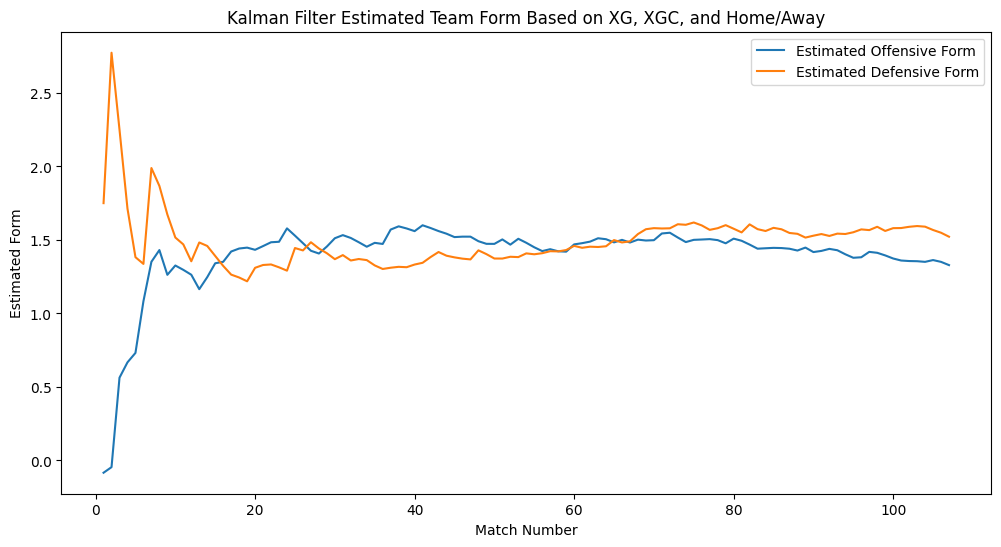

In [21]:
import pandas as pd

df=pd.read_csv("Team_data_transformed.csv")
code=1
home=1
team_df=df[df["code"]==code]
#team_df=team_df[team_df["was_home"]==home]

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Setup: Dummy Data Simulation
# -----------------------------
n_matches = len(team_df)  # number of matches

# Simulated measurements for expected goals (XG) and expected goals conceded (XGC)
XG = team_df["XG"].values
XGC = team_df["XGC"].values

# Home/Away indicator: +1 indicates home, -1 indicates away.
home_away = team_df["was_home"].values

# Set home advantage effect constants.
adv_off = 0.10  # extra expected goals when playing home
adv_def = -0.1  # reduced expected goals conceded when playing home

# ---------------------------------
# 2D Kalman Filter Setup
# ---------------------------------

# Define dimensions:
state_dim = 2        # [offensive form, defensive form]
measurement_dim = 2  # [XG, XGC]

# State transition matrix F (assume random walk: state tends to persist)
F = np.eye(state_dim)

# Process noise covariance Q (small process noise, can be tuned)
Q = np.eye(state_dim) * 1e-4

# Observation matrix H (direct observation of state)
H = np.eye(state_dim)

# Measurement noise covariance R (measurement uncertainty)
R = np.eye(measurement_dim) * 0.2

# Initial state estimate (start at zero form) and covariance
x = np.zeros((state_dim, 1))
P = np.eye(state_dim)

# Array to store filtered estimates
filtered_estimates = np.zeros((n_matches, state_dim))

# ---------------------------------
# 3. Kalman Filter Loop
# ---------------------------------
for k in range(n_matches):
    # ---- Prediction Step ----
    x_prior = F @ x  # predict state
    P_prior = F @ P @ F.T + Q  # predict error covariance
    
    # ---- Compute the measurement offset ----
    # Adjust based on the home/away indicator.
    # If home (h = +1), offset = [adv_off, adv_def].
    # If away (h = -1), offset = [-adv_off, -adv_def].
    offset = np.array([[adv_off * home_away[k]],
                       [adv_def * home_away[k]]])
    
    # ---- Measurement ----
    z = np.array([[XG[k]],
                  [XGC[k]]])
    
    # ---- Update Step ----
    # Innovation (measurement residual)
    y = z - (H @ x_prior + offset)
    
    # Innovation covariance
    S = H @ P_prior @ H.T + R
    
    # Kalman Gain calculation
    K = P_prior @ H.T @ np.linalg.inv(S)
    
    # Updated state estimate incorporating the measurement
    x = x_prior + K @ y
    
    # Updated error covariance
    P = (np.eye(state_dim) - K @ H) @ P_prior
    
    # Save the filtered estimates for analysis
    filtered_estimates[k] = x.flatten()

# -----------------------------
# 4. Plotting the Results
# -----------------------------
matches = np.arange(1, n_matches + 1)
team_df["offensive_filters"]=filtered_estimates[:, 0]
team_df["defensive_filters"]=filtered_estimates[:, 1]
print(team_df)
plt.figure(figsize=(12, 6))
plt.plot(matches, filtered_estimates[:, 0], label='Estimated Offensive Form')
plt.plot(matches, filtered_estimates[:, 1], label='Estimated Defensive Form')
plt.xlabel('Match Number')
plt.ylabel('Estimated Form')
plt.title('Kalman Filter Estimated Team Form Based on XG, XGC, and Home/Away')
plt.legend()
plt.show()

In [38]:
import pandas as pd
from scipy.stats import linregress
import xgboost as xgb
import numpy as np

def rolling_slope(sub_df):
    if len(sub_df) < 1:  # Need at least 2 points for regression
        return np.nan
    x = np.arange(len(sub_df))  # Create a time index [0,1,2,...]
    y = sub_df  # Get values of the rolling window
    slope, _, _, _, _ = linregress(x, y)  # Compute regression slope
    return slope      

def team_transformed2():
    df=pd.read_csv("Team_data_transformed.csv").iloc[:,1:]
    codes=df['code'].unique()

    new_df=pd.DataFrame()
    for code in codes:
        team_df = df[df["code"] == code].copy()
        df_opponent = df[['code', 'kickoff_time', 'XGA', 'XGCA', 'XGH', 'XGCH','XG_avg','XGC_avg']].copy()

        merged = team_df.merge(df_opponent,
                       how='left',
                       left_on=['opponent', 'kickoff_time'],
                       right_on=['code', 'kickoff_time'],
                       suffixes=('', '_opp'))

        merged.drop(columns='code_opp', inplace=True, errors='ignore')
        own_xg=[]
        own_xgc=[]
        opp_xg=[]
        opp_xgc=[]
        own_avg_xg=[]
        own_avg_xgc=[]
        opp_avg_xg=[]
        opp_avg_xgc=[]
        for j in range(len(merged)):
            home=merged["was_home"].values[j]
            if home:
                own_xg.append(merged["XGH"].values[j])
                own_xgc.append(merged["XGCH"].values[j])
                opp_xg.append(merged["XGA_opp"].values[j])
                opp_xgc.append(merged["XGCA_opp"].values[j])
            else:
                own_xg.append(merged["XGA"].values[j])
                own_xgc.append(merged["XGCA"].values[j])
                opp_xg.append(merged["XGH_opp"].values[j])
                opp_xgc.append(merged["XGCH_opp"].values[j])
                
            own_avg_xg.append(merged["XG_avg"].values[j])
            own_avg_xgc.append(merged["XGC_avg"].values[j])
            opp_avg_xg.append(merged["XG_avg_opp"].values[j])
            opp_avg_xgc.append(merged["XGC_avg_opp"].values[j])
            
        train_df=pd.DataFrame()
        train_df["Own_XG"]=own_xg
        train_df["Own_XGC"]=own_xgc
        train_df["opp_XG"]=opp_xg
        train_df["opp_XGC"]=opp_xgc
        
        train_df["Own_avg_XG"]=own_avg_xg
        train_df["Own_avg_XGC"]=own_avg_xgc
        train_df["opp_avg_XG"]=opp_avg_xg
        train_df["opp_avg_XGC"]=opp_avg_xgc
        
        train_df["XG"]=merged["XG"].values
        train_df["XGC"]=merged["XG"].values
        train_df[["Own_XG","Own_XGC","opp_XG","opp_XGC","XG","XGC","Own_avg_XG","Own_avg_XGC","opp_avg_XG","opp_avg_XGC"]].round(1)
        train_df['XG'] = train_df['XG'].clip(lower=0.7, upper=2.5)
        train_df['XGC'] = train_df['XGC'].clip(lower=0.7, upper=2.5)
        new_df=pd.concat([new_df, train_df], axis=0, ignore_index=True)


    train_xg=new_df[["Own_XG","opp_XGC","Own_avg_XG","opp_avg_XGC" ]]
    y_xg=new_df["XG"]
    model_xg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=50, learning_rate=0.1, max_depth=3,min_child_weight=4)
    model_xg.fit(train_xg, y_xg)

    train_xgc=new_df[["Own_XGC","opp_XG","Own_avg_XGC","opp_avg_XG"]]
    y_xgc=new_df["XGC"]
    model_xgc = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=50, learning_rate=0.1, max_depth=3,min_child_weight=4)
    model_xgc.fit(train_xgc, y_xgc)

    df=pd.read_csv("Team_data_transformed.csv").iloc[:,1:]
    codes=df['code'].unique()
    full_df=pd.DataFrame()
    new_team_df=pd.DataFrame()
    for code in codes:

        team_df = df[df["code"] == code].copy()

        df_opponent = df[['code', 'kickoff_time', 'XGA', 'XGCA', 'XGH', 'XGCH','XG_avg','XGC_avg']].copy()

        merged = team_df.merge(df_opponent,
                       how='left',
                       left_on=['opponent', 'kickoff_time'],
                       right_on=['code', 'kickoff_time'],
                       suffixes=('', '_opp'))

        # Optionally, drop the redundant 'code' column from the opponent side.
        merged.drop(columns='code_opp', inplace=True, errors='ignore')
        merged['XG'] = merged['XG'].clip(lower=0.7, upper=2.5)
        merged['XGC'] = merged['XGC'].clip(lower=0.7, upper=2.5)
        new_XGH=[]
        new_XGCH=[]
        new_XGA=[]
        new_XGCA=[]
        new_XG_avg=[]
        new_XGC_avg=[]
        current_XGH=1.5
        current_XGA=1.5
        current_XGCH=1.5
        current_XGCA=1.5
        total_XG=1.5
        total_XGC=1.5
        smoothing_f=0.1
        min_val=1

        for i in range(len(merged)):
            home=merged["was_home"].values[i]
            if home:
                
                
                xg_prediction=model_xg.predict([[current_XGH,merged["XGCA_opp"].values[i],total_XG,merged["XGC_avg_opp"].values[i]]] )[0]
                xgc_predictions=model_xgc.predict([[current_XGCH,merged["XGA_opp"].values[i],total_XGC,merged["XG_avg_opp"].values[i] ]])[0]

                opp_xgc=model_xgc.predict([[merged["XGCA_opp"].values[i],current_XGH, merged["XGC_avg_opp"].values[i],total_XG]])[0]

                opp_xg=model_xg.predict([[merged["XGA_opp"].values[i],current_XGCH,merged["XG_avg_opp"].values[i],total_XGC]] )[0]
                pred_xg_1=0.5*opp_xgc+0.5*xg_prediction
                pred_xgc_1=0.5*opp_xg+0.5*xgc_predictions

                pred_xg=0.5*current_XGH+0.25*merged["XGCA_opp"].values[i]+0.25*pred_xg_1
                pred_xgc=0.5*current_XGCH+0.25*merged["XGA_opp"].values[i]+0.25*pred_xgc_1

               
                new_XGH.append(max(0.7,current_XGH+smoothing_f*min(min_val,max(-min_val,(merged["XG"].values[i])-(pred_xg)))))

        
                current_XGH=new_XGH[-1]
                new_XGCH.append(max(0.6,current_XGCH+smoothing_f*min(min_val,max(-min_val,(merged["XGC"].values[i])-(pred_xgc)))))
                current_XGCH=new_XGCH[-1]

                new_XGA.append(current_XGA)
                new_XGCA.append(current_XGCA)

    
        
            else:
                xg_prediction=model_xg.predict([[current_XGA,merged["XGCH_opp"].values[i],total_XG,merged["XGC_avg_opp"].values[i]]] )[0]
                xgc_predictions=model_xgc.predict([[current_XGCA,merged["XGH_opp"].values[i],total_XGC,merged["XG_avg_opp"].values[i] ]])[0]

                opp_xgc=model_xgc.predict([[merged["XGCH_opp"].values[i],current_XGA, merged["XGC_avg_opp"].values[i],total_XG]])[0]

                opp_xg=model_xg.predict([[merged["XGH_opp"].values[i],current_XGCA,merged["XG_avg_opp"].values[i],total_XGC]])[0]

                pred_xg_1=0.5*xg_prediction+opp_xgc*0.5

                pred_xgc_1=0.5*opp_xg+0.5*xgc_predictions

                pred_xg=0.5*current_XGA+0.25*merged["XGCH_opp"].values[i]+0.25*pred_xg_1
                pred_xgc=0.5*current_XGCA+0.25*merged["XGH_opp"].values[i]+0.25*pred_xgc_1
        
                new_XGA.append(max(0.7,current_XGA+smoothing_f*min(min_val,max(-min_val,((merged["XG"].values[i])-pred_xg)))))
                current_XGA=new_XGA[-1]
                new_XGCA.append(max(0.6,current_XGCA+smoothing_f*min(min_val,max(-min_val,(merged["XGC"].values[i]-pred_xgc)))))
                current_XGCA=new_XGCA[-1]

                new_XGH.append(current_XGH)
                new_XGCH.append(current_XGCH)
        
            xg_prediction=model_xg.predict([[total_XG,merged["XGC_avg_opp"].values[i],total_XG,merged["XGC_avg_opp"].values[i]]] )[0]
            xgc_predictions=model_xgc.predict([[total_XGC,merged["XG_avg_opp"].values[i],total_XGC,merged["XG_avg_opp"].values[i] ]])[0]
            
            opp_xgc=model_xgc.predict([[merged["XGC_avg_opp"].values[i],total_XG, merged["XGC_avg_opp"].values[i],total_XG]])[0]

            opp_xg=model_xg.predict([[merged["XG_avg_opp"].values[i],total_XGC,merged["XG_avg_opp"].values[i],total_XGC]])[0]

            pred_xg_1=0.5*xg_prediction+opp_xgc*0.5
            pred_xg=0.5*total_XG+0.25*merged["XGC_avg_opp"].values[i]+0.25*pred_xg_1

            pred_xgc_1=0.5*opp_xg+0.5*xgc_predictions
            pred_xgc=0.5*total_XGC+0.25*merged["XG_avg_opp"].values[i]+0.25*pred_xgc_1
            
            
            print("XG")
            print(merged["XG"].values[i])
            print(pred_xg)
                
            print("XGC")
            print(merged["XGC"].values[i])
            print(pred_xgc)

            new_XG_avg.append(max(0.7,total_XG+smoothing_f*min(min_val,max(-min_val,(merged["XG"].values[i])-pred_xg))))
            total_XG=new_XG_avg[-1]

            new_XGC_avg.append(max(0.6,total_XGC+smoothing_f*min(min_val,max(-min_val,(merged["XGC"].values[i]-pred_xgc)))))
            total_XGC=new_XGC_avg[-1]

        
        team_df.replace([np.inf, -np.inf], np.nan, inplace=True)
        team_df.fillna(1.5, inplace=True)
        
        """team_df["XGH"]=np.array(new_XGH, dtype=float)*0.5+team_df["XGH"].values*0.5
        team_df["XGCH"]=np.array(new_XGCH, dtype=float)*0.5+team_df["XGCH"].values*0.5 
        team_df["XGA"]=np.array(new_XGA, dtype=float)*0.5+team_df["XGA"].values*0.5  
        team_df["XGCA"]=np.array(new_XGCA, dtype=float)*0.5+team_df["XGCA"].values*0.5 
        team_df["XG_avg"]=np.array(new_XG_avg, dtype=float)*0.5+team_df["XG_avg"].values*0.5 
        team_df["XGC_avg"]=np.array(new_XGC_avg, dtype=float)*0.5+team_df["XGC_avg"].values*0.5"""
        team_df["XGH"]=np.array(new_XGH, dtype=float)
        team_df["XGCH"]=np.array(new_XGCH, dtype=float)
        team_df["XGA"]=np.array(new_XGA, dtype=float)
        team_df["XGCA"]=np.array(new_XGCA, dtype=float)
        team_df["XG_avg"]=np.array(new_XG_avg, dtype=float)*0.5+team_df["XG_avg"].values*0.5 
        team_df["XGC_avg"]=np.array(new_XGC_avg, dtype=float)*0.5+team_df["XGC_avg"].values*0.5
        team_df['XG_slope']=team_df['XG_avg'].rolling(window=8, min_periods=1).apply(rolling_slope, raw=True)
        team_df['XGC_slope']=team_df['XGC_avg'].rolling(window=8, min_periods=1).apply(rolling_slope, raw=True)
    
        new_team_df=pd.concat([new_team_df, team_df.iloc[-1:,:]], axis=0, ignore_index=True)
        team_df["XGCH"]=team_df["XGCH"].shift(1, fill_value=1.5)
        team_df["XGH"]=team_df["XGH"].shift(1, fill_value=1.5)
        team_df["XGA"]=team_df["XGA"].shift(1, fill_value=1.5)
        team_df["XGCA"]=team_df["XGCA"].shift(1, fill_value=1.5)
        team_df["XG_avg"]=team_df["XG_avg"].shift(1, fill_value=0)
        team_df["XGC_avg"]=team_df["XGC_avg"].shift(1, fill_value=0)
        team_df["XG_slope"]=team_df["XG_slope"].shift(1, fill_value=0)
        team_df["XGC_slope"]=team_df["XGC_slope"].shift(1, fill_value=0)

        full_df=pd.concat([full_df, team_df], axis=0, ignore_index=True)
    
    full_df.to_csv("Team_data_transformed2.csv")
    new_team_df.to_csv("Team_data_newest2.csv")


team_transformed2()

XG
1.0
1.557826042175293
XGC
2.5
1.3974521160125732
XG
2.0
1.421721374988556
XGC
2.0
1.5128594219684601
XG
2.0
1.4030181092023848
XGC
1.0
1.5128995141386987
XG
0.7
1.4524900958836078
XGC
1.0
1.4902223132997752
XG
2.0
1.4332252521917224
XGC
1.0
1.4823167834483089
XG
0.7
1.5012456030274182
XGC
1.0
1.3997422882032766
XG
0.7
1.4234718515568487
XGC
1.0
1.411822234263694
XG
1.0
1.4700579373428062
XGC
2.0
1.3833115726084926
XG
0.7
1.4210630875795478
XGC
2.5
1.4899685559573617
XG
1.0
1.3913657254845821
XGC
1.0
1.498143023044154
XG
1.0
1.3205069569277146
XGC
0.7
1.478670384983987
XG
1.0
1.3244311048737178
XGC
1.0
1.4748893010375221
XG
0.7
1.2700727991703609
XGC
1.0
1.397518984116063
XG
1.0
1.2974326588532614
XGC
2.5
1.4271371226063352
XG
1.0266
1.291465602212173
XGC
2.4928
1.4500359933128935
XG
1.45705
1.247845708961458
XGC
1.8204
1.4902029554596525
XG
0.897
1.2493426664390292
XGC
1.7668
1.5251747503593993
XG
0.7
1.2317255331170776
XGC
1.18345
1.4958788856708667
XG
1.62215
1.2277672359782068
XG

In [151]:
Players

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=50, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
df=pd.read_csv("testML3.csv").iloc[:,1:]

def adjust_measure(df, measure_name):  
    player_df=df.copy()
    clipper_val=player_df[measure_name].max()
    std=player_df[measure_name].std()
    print(std)
    #player_df[measure_name] = player_df[measure_name].clip(lower=0.0, upper=1.5)
    n_matches=len(player_df)
    new_expected_goals=[]
    current_expected_goals_start_value=player_df[measure_name].mean()
    current_expected_goals=current_expected_goals_start_value
    smoothing_f=0.08
    min_val=std*1.5
    count=0
    for i in range(len(player_df)):
        count+=1
        offset=max(1,2-count*0.05)
        home=player_df["was_home"].values[i]
        if home:
            pred_scored=current_expected_goals*player_df["XGCA"].values[i]*np.minimum(1, player_df['minutes'].values[i] / 70)

            new_expected_goals.append(min(clipper_val,current_expected_goals+offset*smoothing_f*min(min_val,max(-min_val,player_df[measure_name].values[i]-pred_scored))))
            current_expected_goals=new_expected_goals[-1]
                
        else:
            pred_scored=current_expected_goals*player_df["XGCH"].values[i]*np.minimum(1, player_df['minutes'].values[i] / 70)

            new_expected_goals.append(min(clipper_val,current_expected_goals+offset*smoothing_f*min(min_val,max(-min_val,player_df[measure_name].values[i]-pred_scored))))
            current_expected_goals=new_expected_goals[-1]
    return new_expected_goals


name_list=['Mohamed_Salah','Ollie_Watkins','Antoine_Semenyo','Bryan_Mbeumo','João_Pedro Junqueira de Jesus','Danny_Welbeck','Nicolas_Jackson','Jean-Philippe_Mateta','Dominic_Calvert-Lewin','Diogo_Teixeira da Silva'
      ,'Erling_Haaland','Alexander_Isak','Matheus_Santos Carneiro Da Cunha','Dominic_Solanke','Gabriel_dos Santos Magalhães','William_Saliba','Lucas_Digne','Ezri_Konsa Ngoyo','Lewis_Dunk','Levi_Colwill0','Antonee_Robinson','Trent_Alexander-Arnold','Andrew_Robertson',
      'Joško_Gvardiol','Rico_Lewis','Diogo_Dalot Teixeira','Dan_Burn','Pedro_Porro','Rayan_Aït-Nouri','Gabriel_Martinelli Silva','Bukayo_Saka','Martin_Ødegaard','Morgan_Rogers','Antoine_Semenyo','Marcus_Tavernier','Bryan_Mbeumo','Noni_Madueke','Eberechi_Eze','Dwight_McNeil','Diogo_Teixeira da Silva','Luis_Díaz','Mohamed_Salah','Phil_Foden','Bruno_Borges Fernandes',
      'Morgan_Gibbs-White','Dejan_Kulusevski','James_Maddison1','Jarrod_Bowen','Marco_Asensio']
name_list=['Bukayo_Saka']
for j in range(len(name_list)):
    name=name_list[j]
    new_df=df[df['name'] == name]
    new_expected_goals=adjust_measure(new_df, 'expected_goals')
    sa=pd.DataFrame()
    print(new_df['Adjusted_XG'].ewm(span=12, adjust=False).mean())
    sa["A2"]=new_expected_goals

print(sa)


    
0.0928

"""
plt.plot(new_expected_goals)

plt.xlabel('Match Number')
plt.ylabel('Estimated Form')
plt.title('Kalman Filter Estimated Team Form Based on XG, XGC, and Home/Away')
plt.legend()
plt.show()"""

0.3580613226713872
789    0.000000
790    0.000000
791    0.000000
792    0.000000
793    0.000000
         ...   
882    0.196150
883    0.210589
884    0.213575
885    0.200717
886    0.214453
Name: Adjusted_XG, Length: 98, dtype: float64
          A2
0   0.239093
1   0.168953
2   0.129195
3   0.102219
4   0.079894
..       ...
93  0.259618
94  0.263333
95  0.290818
96  0.274769
97  0.259315

[98 rows x 1 columns]


"\nplt.plot(new_expected_goals)\n\nplt.xlabel('Match Number')\nplt.ylabel('Estimated Form')\nplt.title('Kalman Filter Estimated Team Form Based on XG, XGC, and Home/Away')\nplt.legend()\nplt.show()"